# Trening pico-gpt (NumPy) — TinyStories

Ovaj notebook pokreće čist NumPy trening transformer modela (`PicoGPTOracle`) na TinyStories. Dimenzije:

- `B = 32`   — batch size
- `T = 128`  — block (context) size
- `C = 256`  — d_model
- `L = 4`    — broj transformer blokova
- `NH = 8`   — broj attention glava

In [11]:

from layers.oracle import PicoGPTOracle

VOCAB_STR = (" \n\t0123456789abcdefghijklmnopqrstuvwxyz"
             "ABCDEFGHIJKLMNOPQRSTUVWXYZ.,?!;:'\"-—…()[]{}*_&$%/\\Code“”‘’")

def build(tokenizer, T, C, L, NH):
    return PicoGPTOracle(vocab_size=tokenizer.vocab_size, d_model=C,
                         n_layers=L, n_heads=NH, max_seq_len=T)

Definišemo vokabular od 78 karaktera (slova, cifre, interpunkcija, navodnici, specijalni simboli uključujući `Code`). `build(...)` je factory koji pravi instancu modela sa zadatim hiperparametrima.

In [ ]:
from data_handling.chunker_loader import ChunkerLoader

chunker_loader = ChunkerLoader(stories_per_chunk=10000, max_chunks=10)
chunker_loader.create_chunks()

`ChunkerLoader` u streaming modu čita TinyStories, secka ga na chunk-ove od po 10 000 priča (maks 10 chunk-ova) i čuva u `data/`. Tako dobijamo lokalne fajlove `train_chunk_*.txt` i jedan `tiny_stories_val.txt`.

In [12]:

from data_handling.batch_loader_np import DynamicBatchLoaderNp
from data_handling.tokenizer import CharacterTokenizer
from layers.runner import Runner

def train():
    tokenizer = CharacterTokenizer(VOCAB_STR)
    B, T = 32, 128
    C, L, NH = 256, 4, 8
    loader = DynamicBatchLoaderNp("../notebooks/data", B, T,
                                swap_every_iterations=100,
                                char_to_int=tokenizer.stoi)
    model = build(tokenizer, T, C, L, NH)
    runner = Runner(model, loader, tokenizer, B, T, max_steps=2000, eval_interval=200)
    history = runner.train()
    runner.plot_evaluation(history, vocab_size=tokenizer.vocab_size)
    runner.print_summary(history)
    return history

`train()` pravi `CharacterTokenizer`, `DynamicBatchLoaderNp` koji rotira chunk-ove svakih 100 iteracija, instancira model i pokreće `Runner` na 2000 koraka sa evaluacijom na svakih 200. Na kraju iscrtava `training_eval_dashboard.png` (train/val loss, perplexity, generalization gap, generaciona entropija) i štampa rezime.

Starting standalone execution loop pipeline...
[Data Loader] train iter 0: loading ../notebooks/data/train_chunk_1.txt
[Data Loader] val iter 0: loading ../notebooks/data/tiny_stories_val.txt
Step    0 | Train 5.0218 | Val 4.9577 | PPL  142.27 | Gap -0.0641 | top1 0.002 top5 0.019 | H(0.7) 3.54 H(1.0) 4.04
[Data Loader] train iter 100: loading ../notebooks/data/train_chunk_10.txt
[Data Loader] train iter 200: loading ../notebooks/data/train_chunk_2.txt
Step  200 | Train 2.1671 | Val 2.1984 | PPL    9.01 | Gap +0.0313 | top1 0.345 top5 0.720 | H(0.7) 1.77 H(1.0) 2.37
[Data Loader] train iter 300: loading ../notebooks/data/train_chunk_3.txt
[Data Loader] train iter 400: loading ../notebooks/data/train_chunk_4.txt
Step  400 | Train 1.8647 | Val 1.8973 | PPL    6.67 | Gap +0.0326 | top1 0.455 top5 0.799 | H(0.7) 1.38 H(1.0) 1.52
[Data Loader] train iter 500: loading ../notebooks/data/train_chunk_5.txt
[Data Loader] train iter 600: loading ../notebooks/data/train_chunk_6.txt
Step  600 | Tra

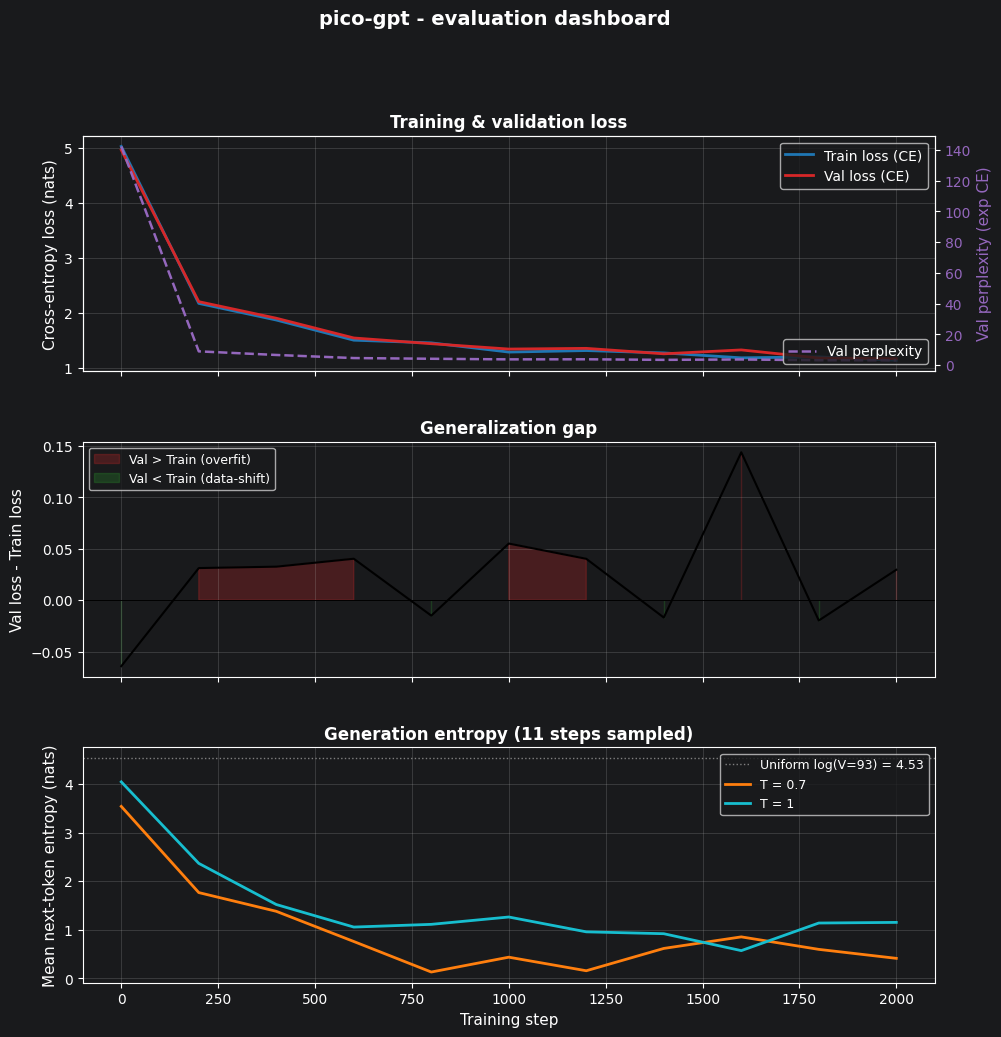

Saved dashboard to training_eval_dashboard.png

Final Results:
  Final train loss:     1.1321
  Final val loss:       1.1616
  Final val perplexity: 3.20
  Final val top-1/5:    0.624 / 0.890
  Best  val loss:       1.1616 (at step 2000)
  Delta val loss (best->end): +0.0000


{'step': [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000],
 'train_loss': [5.0218047317402865,
  2.1671236778167575,
  1.8646950626877428,
  1.4979552007177346,
  1.4490770199245668,
  1.2816118235883522,
  1.309176369209784,
  1.2667347180729196,
  1.1770644791009617,
  1.1940832420461958,
  1.1320644430261564],
 'val_loss': [4.957691556396536,
  2.1983739220027547,
  1.8972961466960891,
  1.5382644005118606,
  1.4340845460387623,
  1.33668336774369,
  1.3494251914754543,
  1.249880457645874,
  1.3208577438083837,
  1.1743592609143803,
  1.1616460808534907],
 'val_ppl': [142.26500580365865,
  9.010350048746119,
  6.6678411821840715,
  4.6565014320243066,
  4.1958021863607184,
  3.8063981241195046,
  3.855208886753079,
  3.4899257385861593,
  3.746633651226486,
  3.236068803651324,
  3.195188488271348],
 'val_top1': [0.0017224409448818897,
  0.3454724409448819,
  0.4554625984251969,
  0.5457677165354331,
  0.562992125984252,
  0.5888287401574803,
  0.6215551181102362,
  0.62

In [13]:
train()

Trening završen. Dashboard sačuvan u `training_eval_dashboard.png`. Ispod su finalni rezultati: train/val loss, val perplexity, top-1/5 accuracy, i najbolji val loss sa delta-om do kraja.

In [20]:
import numpy as np

from data_handling.tokenizer import CharacterTokenizer
from layers.runner import Runner


def infer(checkpoint="pico_gpt_oracle_np", temperature=0.65, max_new_tokens=250):
    tokenizer = CharacterTokenizer(VOCAB_STR)
    B, T = 32, 128
    C, L, NH = 256, 4, 8
    model = build(tokenizer, T, C, L, NH)
    print(f"Loading weights from '{checkpoint}.npz'...")
    model.load(checkpoint)
    model.fuse_norms_for_inference()
    runner = Runner(model, batch_loader=None, tokenizer=tokenizer, B=B, T=T)

    prompt = ""
    while prompt != "q":
        prompt = input("Prompt: ")
        if prompt == "q":
            break
        ctx = np.array([tokenizer.encode(prompt)], dtype=np.int64)
        out = runner.generate_text(ctx, max_new_tokens=max_new_tokens,
                                   block_size=T, temperature=temperature, inference=False)
        print("\n--- Model Output ---")
        print(tokenizer.decode(out[0].tolist()))
        print("--------------------")

`infer()` učitava sačuvane težine iz `pico_gpt_oracle_np.npz`, fuzuje LayerNorm za inferenciju (`fuse_norms_for_inference`), i otvara interaktivnu petlju: na svaki prompt generiše 250 tokena sa temperaturom 0.65. `q` izlazi iz petlje.

In [21]:
infer()

Loading weights from 'pico_gpt_oracle_np.npz'...

--- Model Output ---
anna said. They have so pick it up and around it. They had a back to her friends. They are want to her farm the park to have to help and took the bad to mestione. They can to the clothes and and very curious and the ball and went to the little boy careful bet
--------------------


KeyboardInterrupt: Interrupted by user

Model generiše tekst u TinyStories stilu — kratke, dečje rečenice na engleskom. Primer izlaza vidimo iznad (iz prethodnog pokretanja).